# Archaea specieswise penalized-likelihood optimization

Interactive notebook for fitting DTL rates on the AleRax Archaea dataset by **penalized
likelihood** (Sanderson 2002): `NLL(theta) + λ·Φ(theta)`, with `Φ` a roughness penalty that
smooths rates across the species tree and `λ` chosen by cross-validation. Use `specieswise`
mode (rates live on the species tree). It exposes family selection, model construction,
Pi/Neumann/self-loop-solver schedules, the smoothing parameter and its cross-validation, an
optional L-BFGS refinement, and plotting of loss, gradients, rates, and the penalty.

## Safety defaults

The notebook is safe to execute top-to-bottom by default. It loads helper code and plots an existing result JSON if available, but it does **not** build the full GPU model or start optimization unless `BUILD_MODEL = True` and `RUN_OPTIMIZATION = True` in the configuration cell.

In [1]:
from __future__ import annotations

from pathlib import Path
from types import SimpleNamespace
import importlib.util
import json
import math
import os
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

CWD = Path.cwd()
REPO = CWD if (CWD / "gpurec").exists() else CWD.parent if (CWD.parent / "gpurec").exists() else CWD
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from gpurec import GeneReconModel, SolverOptions, clamp_log_rate_

SCRIPT_PATH = REPO / "scripts/optimize_alerax_archaea_genewise_adam.py"
spec = importlib.util.spec_from_file_location("archaea_opt", SCRIPT_PATH)
archaea_opt = importlib.util.module_from_spec(spec)
assert spec.loader is not None
spec.loader.exec_module(archaea_opt)

plt.rcParams.update({"figure.dpi": 130, "axes.grid": True})
torch.set_float32_matmul_precision("high")

REPO


PosixPath('/home/enzo/Documents/git/gpurec/gpurec')

## Configuration

Edit this cell to choose `MODE = "genewise"` or `MODE = "specieswise"`, a subset/full dataset, resume checkpoint, optimizer, and solver schedule. A schedule entry is:

```text
STEPS:PI_ITERS:NEUMANN_TERMS:DTYPE:SELF_LOOP_SOLVER:LR
```

`SELF_LOOP_SOLVER` is the backward/adjoint self-loop solver: `neumann` or `gmres`. It does not replace the normal forward likelihood solver.

For `genewise`, each row of `theta` is a gene family. For `specieswise`, each row of `theta` is a species-tree node.

In [2]:
DATA_ROOT = REPO / "tests/data/alerax_archaea_davin2017"
SPECIES_TREE = DATA_ROOT / "species_reference/reference_species_tree.newick"
FAMILY_DIR = DATA_ROOT / "ale_gene_tree_distributions/main_families_ge4seq"
RESULT_DIR = REPO / "output/alerax_archaea_genewise_adam"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

# Execution controls. Leave all False for a safe analysis-only execution.
BUILD_MODEL = True
RUN_OPTIMIZATION = True

# Optional quasi-Newton (L-BFGS) refinement of theta after the first-order schedule,
# minimizing the same penalized objective. Mode-agnostic (operates on the full theta).
RUN_REFINEMENT = True
REFINE_STEPS = 20
REFINE_MAX_ITER = 4          # inner L-BFGS iterations per outer step
REFINE_HISTORY_SIZE = 10
REFINE_LINE_SEARCH = "strong_wolfe"
REFINE_DTYPE = "float32"
REFINE_PI_ITERS = 16
REFINE_NEUMANN_TERMS = 16
REFINE_SELF_LOOP_SOLVER = "neumann"
REFINE_PRINT_EVERY = 1

# Cross-validation for the smoothing parameter (Sanderson 2002, k-fold over families).
# Expensive: folds x len(grid) full fits. Off by default; keep the subset small.
RUN_CV = True
CV_MAX_FAMILIES = 0         # subset used only for CV (0 = all eligible families)
CV_FOLDS = 3
CV_LAMBDA_GRID = [0.1, 0.3, 1.0, 3.0, 10.0, 30.0, 100.0]
CV_STEPS = 60               # optimization steps per (fold, lambda) fit
CV_DTYPE = "float32"

# Use 0 for all eligible families. Start small for a quick first specieswise run.
MAX_FAMILIES = 0
MIN_LEAVES = 4
FAMILY_ORDER = "smallest"  # smallest, largest, lexicographic
RECURSIVE_FAMILY_SEARCH = False

# Sanderson's roughness penalty smooths rates across the species tree, so the rate
# parameters must live on that tree: specieswise (theta = D/T/L per species node).
MODE = "specieswise"  # specieswise (penalized) or genewise (no tree, penalty inactive)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 20260609

# Packing controls used for the whole archaeal dataset.
FAMILY_CHUNK_SIZE = 0
CLADE_BUDGET = 300_000
BATCH_PACKING = "depth_first_fit"
MAX_WAVE_SIZE = 8192

# Initialization. Set INIT_JSON to resume theta from a previous run.
THETA_INIT_RATE = 0.05
INIT_JSON = None

# Sanderson penalized-likelihood smoothing parameter lambda. Objective is
# NLL + PENALTY_LAMBDA * Phi(theta), with Phi the roughness penalty over the
# species tree. Set PENALTY_LAMBDA = 0 for the (diverging) saturated model, large
# for the clock limit. Run the CV cell to choose it from the data.
PENALTY_LAMBDA = 1.0

# Rate bounds. Penalized-likelihood experiments use unbounded/unprojected rates.
UNBOUNDED_UNPROJECTED = True
MIN_RATE = 1e-10
MAX_RATE = 2.0
CLIP_GRAD_NORM = 200.0

# Optimizer controls.
OPTIMIZER = "adam"  # adam, rmsprop, sgd, rprop, adadelta, adafactor, adamax
OPTIMIZER_LR = None  # if None, each schedule phase LR or optimizer default is used
OPTIMIZER_MOMENTUM = 0.0
ADAM_BETA1 = 0.9
ADAM_BETA2 = 0.95
RMSPROP_ALPHA = 0.99
ADADELTA_RHO = 0.9
OPTIMIZER_EPS = None
PRESERVE_OPTIMIZER_STATE_ACROSS_PHASES = False

# LR shaping inside each phase. Use only ramp or decay, not both.
LR_RAMP_STEPS = 0
LR_RAMP_START_FACTOR = 0.25
LR_RAMP_FIRST_PHASE = False
LR_DECAY_STEPS = 0
LR_DECAY_END_FACTOR = 1.0

# Suggested editable schedule. Start cheap in fp32; reserve fp64+gmres for final checking.
SCHEDULE_TEXT = "20:16:16:float32:neumann:0.1"

# Solver controls outside the schedule.
E_MAX_ITER = 2000
E_TOL = 1e-8

# Convergence checks used when saving summaries.
TAIL_WINDOW = 40
TAIL_SLOPE_TOL = 0.02
MIN_IMPROVEMENT_BITS = 0.0
MAX_PROJECTED_GRAD_NORM = 0.05

OUTPUT_JSON = RESULT_DIR / f"archaea_{MODE}_notebook_run.json"

SCHEDULE = archaea_opt.parse_schedule(SCHEDULE_TEXT)
pd.DataFrame(SCHEDULE)


,steps,pi_iters,neumann_terms,dtype,self_loop_solver,optimizer_lr
0,20,16,16,float32,neumann,0.1


## Build arguments and select families

In [3]:
def make_args() -> SimpleNamespace:
    return SimpleNamespace(
        mode=MODE,
        init_json=INIT_JSON,
        theta_init_rate=THETA_INIT_RATE,
        max_rate=MAX_RATE,
        min_rate=MIN_RATE,
        unbounded_unprojected=UNBOUNDED_UNPROJECTED,
        clip_grad_norm=CLIP_GRAD_NORM,
        optimizer=OPTIMIZER,
        optimizer_lr=OPTIMIZER_LR,
        adam_lr=None,
        optimizer_momentum=OPTIMIZER_MOMENTUM,
        adam_beta1=ADAM_BETA1,
        adam_beta2=ADAM_BETA2,
        rmsprop_alpha=RMSPROP_ALPHA,
        adadelta_rho=ADADELTA_RHO,
        optimizer_eps=OPTIMIZER_EPS,
        preserve_optimizer_state_across_phases=PRESERVE_OPTIMIZER_STATE_ACROSS_PHASES,
        lr_ramp_steps=LR_RAMP_STEPS,
        lr_ramp_start_factor=LR_RAMP_START_FACTOR,
        lr_ramp_first_phase=LR_RAMP_FIRST_PHASE,
        lr_decay_steps=LR_DECAY_STEPS,
        lr_decay_end_factor=LR_DECAY_END_FACTOR,
        penalty_lambda=PENALTY_LAMBDA,
    )


args = make_args()
torch.manual_seed(SEED)

if DEVICE == "cuda" and not torch.cuda.is_available():
    raise RuntimeError("CUDA requested but torch.cuda.is_available() is false")

ale_families, selection = archaea_opt.select_families(
    FAMILY_DIR,
    max_families=MAX_FAMILIES,
    family_order=FAMILY_ORDER,
    min_leaves=MIN_LEAVES,
    recursive=RECURSIVE_FAMILY_SEARCH,
)

pd.Series(selection)

candidate_families           5446
excluded_below_min_leaves      67
eligible_families            5379
selected_families            5379
dtype: int64

## Initialize or resume the model

Set `BUILD_MODEL = True` in the configuration cell before running this cell if you want to allocate the GPU model.

If `INIT_JSON` is set, make sure `MODE`, `MAX_FAMILIES`, `FAMILY_ORDER`, and `MIN_LEAVES` produce the same theta shape as the checkpoint.

In [4]:
state = None

def initialize_state() -> dict:
    clade_budget = None if CLADE_BUDGET == 0 else CLADE_BUDGET
    first_phase = SCHEDULE[0]
    solver_options = SolverOptions(
        e_init=-1000.0,
        e_max_iter=E_MAX_ITER,
        e_tol=E_TOL,
        pi_iters=int(first_phase["pi_iters"]),
        neumann_terms=int(first_phase["neumann_terms"]),
        self_loop_solver=str(first_phase["self_loop_solver"]),
    )
    model = GeneReconModel(
        SPECIES_TREE,
        ale_families,
        mode=MODE,
        device=DEVICE,
        family_chunk_size=FAMILY_CHUNK_SIZE,
        clade_budget=clade_budget,
        batch_packing=BATCH_PACKING,
        max_wave_size=MAX_WAVE_SIZE,
        solver_options=solver_options,
    )
    current_dtype_name = str(first_phase["dtype"])
    model.to(dtype=archaea_opt.torch_dtype(current_dtype_name))
    model.receiver_weights.requires_grad_(False)
    use_rate_bounds = not bool(UNBOUNDED_UNPROJECTED)
    with torch.no_grad():
        model.theta.fill_(math.log2(THETA_INIT_RATE))
        if use_rate_bounds:
            clamp_log_rate_(model.theta, min_rate=MIN_RATE, max_rate=MAX_RATE)
        model.clear_warm_starts()

    archaea_opt.load_initial_state_(args, model=model)
    params = [model.theta]
    base_lr = archaea_opt.optimizer_lr(args)
    current_lr = float(first_phase["optimizer_lr"] or base_lr)
    optimizer = archaea_opt.make_optimizer(params, args, current_lr)

    penalty_active = MODE == "specieswise"
    if not penalty_active and PENALTY_LAMBDA != 0.0:
        print(f"warning: roughness penalty requires specieswise; penalty inactive in mode {MODE!r}")

    return {
        "model": model,
        "optimizer": optimizer,
        "optimizer_params": params,
        "base_lr": base_lr,
        "current_lr": current_lr,
        "current_dtype_name": current_dtype_name,
        "penalty_active": penalty_active,
        "history": [],
        "global_step": 0,
        "use_rate_bounds": use_rate_bounds,
        "t0": time.perf_counter(),
    }


if BUILD_MODEL:
    state = initialize_state()
    print("Model initialized", {"mode": MODE, "theta_shape": tuple(state["model"].theta.shape), "dtype": state["current_dtype_name"], "penalty_active": state["penalty_active"]})
else:
    print("BUILD_MODEL is False. Set it to True to allocate the GPU model.")

Model initialized {'mode': 'specieswise', 'theta_shape': (119, 3), 'dtype': 'float32', 'penalty_active': True}


## Optimization loop

This loop mirrors the standalone script but leaves the state in memory so you can inspect, plot, adjust the schedule, and continue.

In [5]:
def _set_optimizer_lr(optimizer, lr: float) -> None:
    for group in optimizer.param_groups:
        group["lr"] = lr


def penalty_bits(state: dict) -> torch.Tensor:
    """Sanderson roughness penalty term (already scaled by PENALTY_LAMBDA).

    Smooths theta across the species tree (specieswise only); zero otherwise.
    """
    model = state["model"]
    if not state["penalty_active"]:
        return model.theta.new_zeros(())
    return PENALTY_LAMBDA * archaea_opt.roughness_penalty(model.theta, model.species_helpers)


def _loss_backward(state: dict, *, step_label: int) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, dict[str, float]]:
    model = state["model"]
    optimizer = state["optimizer"]
    optimizer.zero_grad(set_to_none=True)
    data_loss = model()
    penalty = penalty_bits(state)
    loss = data_loss + penalty
    if not torch.isfinite(loss).item():
        raise FloatingPointError(f"non-finite loss at step {step_label}: total={loss} data={data_loss} penalty={penalty}")
    loss.backward()
    if model.theta.grad is None or not torch.isfinite(model.theta.grad).all().item():
        raise FloatingPointError(f"non-finite theta gradient at step {step_label}")

    theta_grad = model.theta.grad.detach()
    metrics = {
        # Scale-free theta stationarity. |g_theta|_inf (sup-norm) and the typical
        # per-parameter gradient |g_theta|_rms both -> 0 at an optimum, regardless
        # of how many species nodes theta has.
        "theta_grad_max": float(theta_grad.abs().max().cpu()),
        "theta_grad_rms": float(theta_grad.norm().cpu()) / math.sqrt(theta_grad.numel()),
        "raw_grad_norm": float(theta_grad.norm().cpu()),
    }
    if state["use_rate_bounds"]:
        from gpurec import project_rate_gradient_
        project_rate_gradient_(model.theta, min_rate=MIN_RATE, max_rate=MAX_RATE)
    metrics["projected_grad_norm"] = float(model.theta.grad.detach().norm().cpu())
    if CLIP_GRAD_NORM > 0.0:
        torch.nn.utils.clip_grad_norm_([model.theta], CLIP_GRAD_NORM)
    metrics["clipped_grad_norm"] = float(model.theta.grad.detach().norm().cpu())
    return loss, data_loss, penalty, metrics


def run_schedule(state: dict, schedule: list[dict], *, print_every: int = 10) -> dict:
    model = state["model"]
    for phase_index, phase in enumerate(schedule):
        phase_steps = int(phase["steps"])
        phase_dtype_name = str(phase["dtype"])
        phase_target_lr = float(phase["optimizer_lr"] or state["base_lr"])
        model.configure_solver(
            pi_iters=int(phase["pi_iters"]),
            neumann_terms=int(phase["neumann_terms"]),
            self_loop_solver=str(phase["self_loop_solver"]),
        )
        optimizer_reset = False
        if phase_dtype_name != state["current_dtype_name"]:
            model.to(dtype=archaea_opt.torch_dtype(phase_dtype_name))
            state["current_dtype_name"] = phase_dtype_name
            state["optimizer_params"] = [model.theta]
            state["optimizer"] = archaea_opt.make_optimizer(state["optimizer_params"], args, phase_target_lr)
            state["current_lr"] = phase_target_lr
            optimizer_reset = True
        elif phase_index > 0 and not PRESERVE_OPTIMIZER_STATE_ACROSS_PHASES:
            state["optimizer"] = archaea_opt.make_optimizer(state["optimizer_params"], args, phase_target_lr)
            state["current_lr"] = phase_target_lr
            optimizer_reset = True
        elif phase_target_lr != state["current_lr"]:
            _set_optimizer_lr(state["optimizer"], phase_target_lr)
            state["current_lr"] = phase_target_lr

        model.clear_warm_starts()
        for phase_step in range(phase_steps):
            step_lr = archaea_opt.scheduled_step_lr(phase_target_lr, phase_step=phase_step, phase_index=phase_index, args=args)
            if step_lr != state["current_lr"]:
                _set_optimizer_lr(state["optimizer"], step_lr)
                state["current_lr"] = step_lr
            archaea_opt.sync(torch.device(DEVICE))
            step_t0 = time.perf_counter()
            prev_loss = state["history"][-1]["loss_bits"] if state["history"] else float("nan")
            loss, data_loss, penalty, grad_metrics = _loss_backward(state, step_label=state["global_step"])
            state["optimizer"].step()
            if state["use_rate_bounds"]:
                clamp_log_rate_(model.theta, min_rate=MIN_RATE, max_rate=MAX_RATE)
            archaea_opt.sync(torch.device(DEVICE))

            row = {
                "step": state["global_step"],
                "phase": phase_index,
                "phase_step": phase_step,
                "optimizer": OPTIMIZER,
                "optimizer_lr": state["current_lr"],
                "optimizer_target_lr": phase_target_lr,
                "optimizer_reset_at_phase_start": optimizer_reset,
                "pi_iters": int(phase["pi_iters"]),
                "neumann_terms": int(phase["neumann_terms"]),
                "self_loop_solver": str(phase["self_loop_solver"]),
                "dtype": phase_dtype_name,
                "loss_bits": float(loss.detach().cpu()),
                "data_loss_bits": float(data_loss.detach().cpu()),
                "penalty_bits": float(penalty.detach().cpu()),
                "penalty_lambda": PENALTY_LAMBDA,
                **grad_metrics,
                "loss_delta": float(loss.detach().cpu()) - prev_loss,
                "step_s": time.perf_counter() - step_t0,
                **archaea_opt.theta_stats(model.theta),
            }
            state["history"].append(row)
            if state["global_step"] == 0 or (state["global_step"] + 1) % print_every == 0:
                # Convergence dashboard: total loss and its per-step change (dloss -> 0),
                # the scale-free theta stationarity (|g_theta|inf -> 0), and the value of
                # the roughness penalty term.
                print(
                    f"step={state['global_step'] + 1:04d} phase={phase_index} "
                    f"dtype={phase_dtype_name} lr={state['current_lr']:.4g} "
                    f"loss={row['loss_bits']:.4f} dloss={row['loss_delta']:+.3g} "
                    f"data={row['data_loss_bits']:.4f} penalty={row['penalty_bits']:.4f} "
                    f"|g_theta|inf={row['theta_grad_max']:.3g} |g_theta|rms={row['theta_grad_rms']:.3g} "
                    f"rate=[{row['rate_min']:.3g},{row['rate_max']:.3g}] step_s={row['step_s']:.3f}",
                    flush=True,
                )
            state["global_step"] += 1
    return state


if RUN_OPTIMIZATION:
    if state is None:
        raise RuntimeError("Set BUILD_MODEL=True and run the model initialization cell before optimization.")
    state = run_schedule(state, SCHEDULE, print_every=10)
else:
    print("RUN_OPTIMIZATION is False. Set it to True to run the configured schedule.")

step=0001 phase=0 dtype=float32 lr=0.1 loss=423109.2188 dloss=+nan data=423109.2188 penalty=0.0000 |g_theta|inf=1.06e+03 |g_theta|rms=152 rate=[0.0467,0.0536] step_s=2.644
step=0010 phase=0 dtype=float32 lr=0.1 loss=397220.4062 dloss=-2.49e+03 data=397049.2188 penalty=171.1937 |g_theta|inf=913 |g_theta|rms=123 rate=[0.025,0.1] step_s=1.009
step=0020 phase=0 dtype=float32 lr=0.1 loss=377933.6562 dloss=-1.47e+03 data=377452.8750 penalty=480.7903 |g_theta|inf=644 |g_theta|rms=83.2 rate=[0.0126,0.204] step_s=1.056


## Quasi-Newton (L-BFGS) refinement

Optional refinement of `theta` with `torch.optim.LBFGS` on the **same** penalized objective
(`NLL + λ·Φ`), matching Sanderson's quasi-Newton optimizer. Operates on the full `theta`
(all species nodes), so it works in any mode. Gated by `RUN_REFINEMENT`; chains automatically
after the first-order schedule.

In [6]:
def _prepare_refinement(state: dict) -> None:
    model = state["model"]
    if REFINE_DTYPE not in {"float32", "float64"}:
        raise ValueError("REFINE_DTYPE must be 'float32' or 'float64'")
    if REFINE_LINE_SEARCH not in {"strong_wolfe", None}:
        raise ValueError("REFINE_LINE_SEARCH must be 'strong_wolfe' or None")
    target_dtype = archaea_opt.torch_dtype(REFINE_DTYPE)
    if state["current_dtype_name"] != REFINE_DTYPE:
        model.to(dtype=target_dtype)
        state["current_dtype_name"] = REFINE_DTYPE
        state["optimizer_params"] = [model.theta]
    model.configure_solver(
        pi_iters=REFINE_PI_ITERS,
        neumann_terms=REFINE_NEUMANN_TERMS,
        self_loop_solver=REFINE_SELF_LOOP_SOLVER,
    )
    model.clear_warm_starts()


def run_refinement(state: dict) -> dict:
    _prepare_refinement(state)
    model = state["model"]
    lbfgs = torch.optim.LBFGS(
        [model.theta],
        max_iter=REFINE_MAX_ITER,
        history_size=REFINE_HISTORY_SIZE,
        line_search_fn=REFINE_LINE_SEARCH,
    )

    def closure():
        lbfgs.zero_grad(set_to_none=True)
        loss = model() + penalty_bits(state)
        loss.backward()
        return loss

    for refine_step in range(REFINE_STEPS):
        archaea_opt.sync(torch.device(DEVICE))
        step_t0 = time.perf_counter()
        prev_loss = state["history"][-1]["loss_bits"] if state["history"] else float("nan")
        lbfgs.step(closure)
        if state["use_rate_bounds"]:
            clamp_log_rate_(model.theta, min_rate=MIN_RATE, max_rate=MAX_RATE)

        # Re-evaluate the full penalized objective and theta gradient for logging.
        loss, data_loss, penalty, grad_metrics = _loss_backward(state, step_label=state["global_step"])
        archaea_opt.sync(torch.device(DEVICE))
        row = {
            "step": state["global_step"],
            "phase": "refinement",
            "phase_step": refine_step,
            "optimizer": "lbfgs",
            "optimizer_lr": float("nan"),
            "pi_iters": REFINE_PI_ITERS,
            "neumann_terms": REFINE_NEUMANN_TERMS,
            "self_loop_solver": REFINE_SELF_LOOP_SOLVER,
            "dtype": REFINE_DTYPE,
            "loss_bits": float(loss.detach().cpu()),
            "data_loss_bits": float(data_loss.detach().cpu()),
            "penalty_bits": float(penalty.detach().cpu()),
            "penalty_lambda": PENALTY_LAMBDA,
            **grad_metrics,
            "loss_delta": float(loss.detach().cpu()) - prev_loss,
            "step_s": time.perf_counter() - step_t0,
            **archaea_opt.theta_stats(model.theta),
        }
        state["history"].append(row)
        if refine_step == 0 or (refine_step + 1) % REFINE_PRINT_EVERY == 0:
            print(
                f"refine={refine_step + 1:03d}/{REFINE_STEPS} dtype={REFINE_DTYPE} "
                f"loss={row['loss_bits']:.4f} dloss={row['loss_delta']:+.3g} "
                f"data={row['data_loss_bits']:.4f} penalty={row['penalty_bits']:.4f} "
                f"|g_theta|inf={row['theta_grad_max']:.3g} |g_theta|rms={row['theta_grad_rms']:.3g} "
                f"rate=[{row['rate_min']:.3g},{row['rate_max']:.3g}] step_s={row['step_s']:.3f}",
                flush=True,
            )
        state["global_step"] += 1

    # Rebuild the first-order optimizer so any later schedule continuation has a
    # fresh optimizer over the current theta.
    state["optimizer_params"] = [model.theta]
    state["optimizer"] = archaea_opt.make_optimizer(state["optimizer_params"], args, state["current_lr"])
    return state


if RUN_REFINEMENT:
    if state is None:
        raise RuntimeError("Set BUILD_MODEL=True and run the model initialization cell before refinement.")
    state = run_refinement(state)
else:
    print("RUN_REFINEMENT is False. Set it to True together with RUN_OPTIMIZATION=True to chain L-BFGS after the schedule.")


refine=001/20 dtype=float32 loss=364756.9375 dloss=-1.32e+04 data=363855.6250 penalty=901.3027 |g_theta|inf=577 |g_theta|rms=60.3 rate=[0.012,2.01] step_s=6.448
refine=002/20 dtype=float32 loss=361212.5312 dloss=-3.54e+03 data=359889.5938 penalty=1322.9440 |g_theta|inf=518 |g_theta|rms=48.3 rate=[0.0109,7.19] step_s=6.484
refine=003/20 dtype=float32 loss=360223.3438 dloss=-989 data=358827.1875 penalty=1396.1605 |g_theta|inf=372 |g_theta|rms=36.7 rate=[0.0104,5.47] step_s=6.453
refine=004/20 dtype=float32 loss=359820.2812 dloss=-403 data=358269.6250 penalty=1550.6608 |g_theta|inf=566 |g_theta|rms=46.3 rate=[0.00955,7.44] step_s=6.493
refine=005/20 dtype=float32 loss=359427.4688 dloss=-393 data=357741.9062 penalty=1685.5657 |g_theta|inf=279 |g_theta|rms=30.2 rate=[0.00893,9.65] step_s=6.548
refine=006/20 dtype=float32 loss=359220.7500 dloss=-207 data=357550.5312 penalty=1670.2268 |g_theta|inf=65.9 |g_theta|rms=10 rate=[0.00886,9.5] step_s=6.543
refine=007/20 dtype=float32 loss=359030.500

KeyboardInterrupt: 

## Plotting helpers

Use these on the in-memory `state['history']` after a run, or on a loaded JSON history.

steps                           40.000000
initial_loss_bits           423109.218750
final_loss_bits             356463.406250
improvement_bits             66645.812500
tail_slope_bits_per_step     -1807.902254
final_data_loss_bits        354563.062500
final_penalty_bits            1900.333008
penalty_lambda                   1.000000
final_theta_grad_max            89.632217
final_theta_grad_rms             8.954780
final_rate_min                   0.007111
final_rate_max                5016.953613
median_step_s_post_first         6.332818
dtype: float64

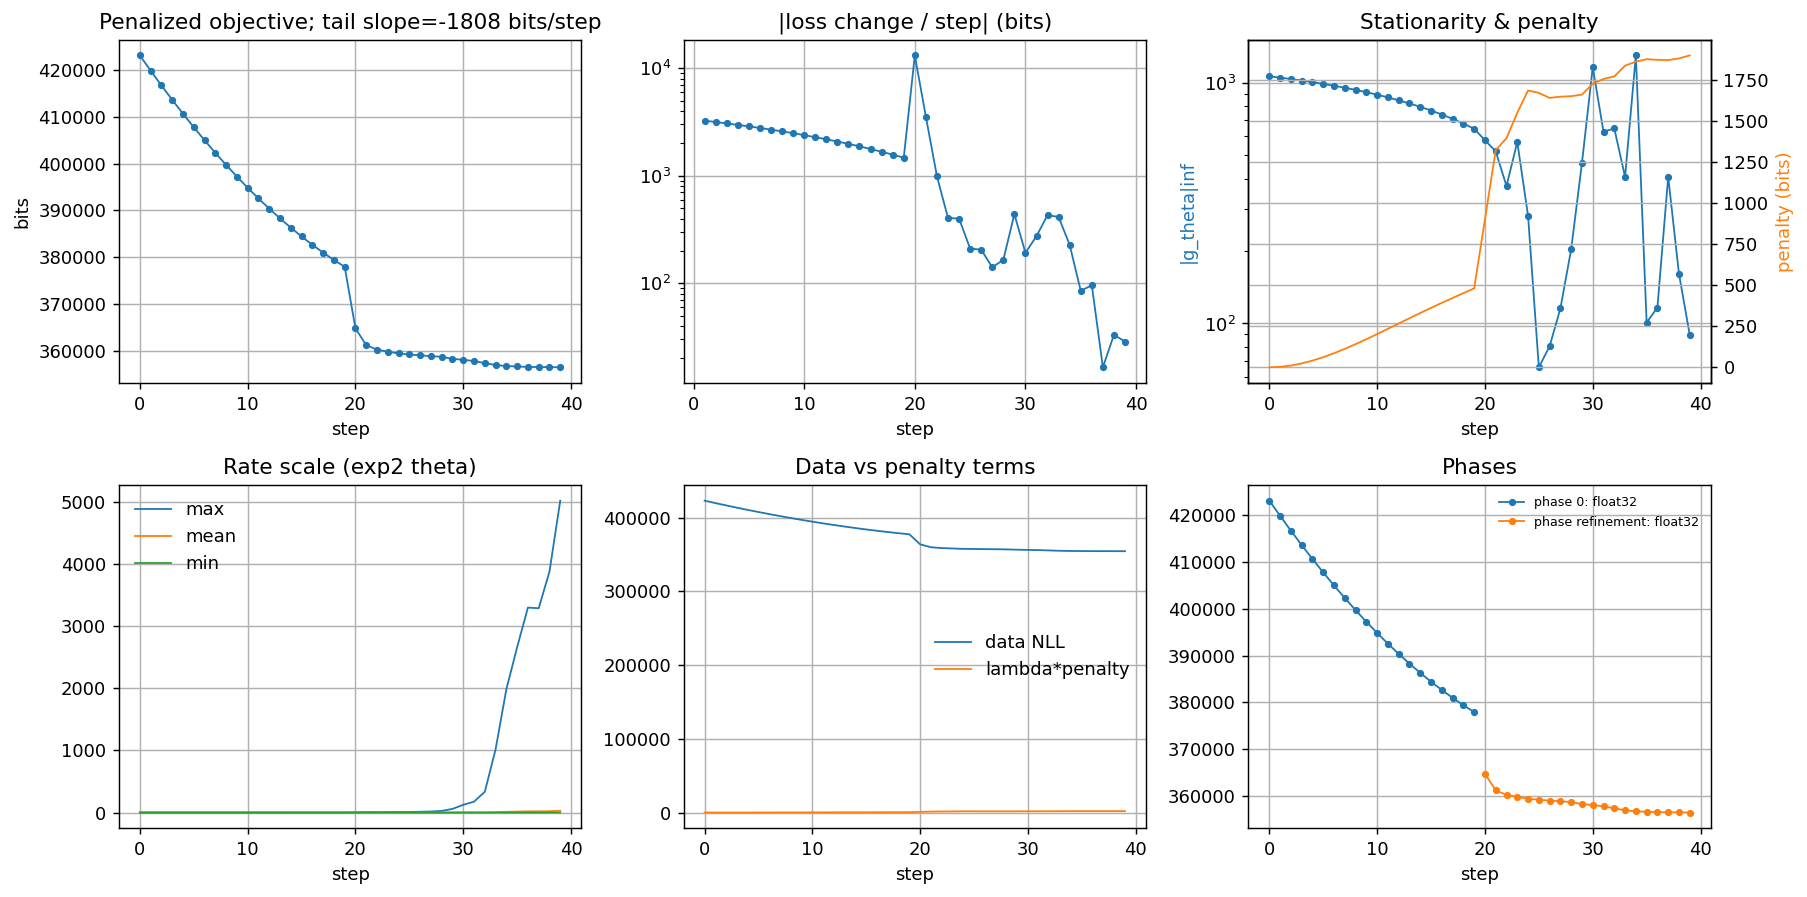

In [ ]:
def history_frame(history: list[dict]) -> pd.DataFrame:
    if not history:
        return pd.DataFrame()
    df = pd.DataFrame(history).copy()
    df["loss_delta_from_start"] = df["loss_bits"] - df["loss_bits"].iloc[0]
    if len(df) >= 2:
        df["step_loss_delta"] = df["loss_bits"].diff()
    return df


def tail_slope(values, window=40) -> float:
    values = np.asarray(values, dtype=float)
    if values.size < 2:
        return 0.0
    tail = values[-min(window, values.size):]
    x = np.arange(tail.size, dtype=float)
    return float(np.polyfit(x, tail, 1)[0])


def _first_present(df: pd.DataFrame, candidates: list[str]) -> str | None:
    for name in candidates:
        if name in df:
            return name
    return None


def plot_history(history: list[dict], *, tail_window: int = 40):
    df = history_frame(history)
    if df.empty:
        print("No history to plot.")
        return None

    fig, axes = plt.subplots(2, 3, figsize=(14, 7))
    ax = axes[0, 0]
    ax.plot(df["step"], df["loss_bits"], marker=".", linewidth=1)
    ax.set_title(f"Penalized objective; tail slope={tail_slope(df['loss_bits'], tail_window):.4g} bits/step")
    ax.set_xlabel("step")
    ax.set_ylabel("bits")

    # |loss change per step| is the most direct convergence signal: it should
    # decay toward 0. Plotted on a log scale (absolute value).
    ax = axes[0, 1]
    if "step_loss_delta" in df:
        ax.plot(df["step"], df["step_loss_delta"].abs(), marker=".", linewidth=1)
        ax.set_yscale("log")
        ax.set_title("|loss change / step| (bits)")
        ax.set_xlabel("step")

    # Theta stationarity (|g_theta|_inf, scale-free) -> 0 at the optimum. The
    # roughness-penalty term is overlaid on a twin axis. Older JSONs without the
    # theta columns fall back to the legacy norms.
    ax = axes[0, 2]
    theta_col = _first_present(df, ["theta_grad_max", "projected_grad_norm"])
    if theta_col is not None:
        ax.plot(df["step"], df[theta_col], marker=".", linewidth=1, color="C0",
                label="|g_theta|inf" if theta_col == "theta_grad_max" else theta_col)
        ax.set_yscale("log")
    ax.set_ylabel("|g_theta|inf", color="C0")
    if "penalty_bits" in df:
        ax2 = ax.twinx()
        ax2.plot(df["step"], df["penalty_bits"], linewidth=1, color="C1", label="penalty")
        ax2.set_ylabel("penalty (bits)", color="C1")
    ax.set_title("Stationarity & penalty")
    ax.set_xlabel("step")

    ax = axes[1, 0]
    ax.plot(df["step"], df["rate_max"], label="max", linewidth=1)
    ax.plot(df["step"], df["rate_mean"], label="mean", linewidth=1)
    ax.plot(df["step"], df["rate_min"], label="min", linewidth=1)
    ax.set_title("Rate scale (exp2 theta)")
    ax.set_xlabel("step")
    ax.legend(frameon=False)

    ax = axes[1, 1]
    if "data_loss_bits" in df:
        ax.plot(df["step"], df["data_loss_bits"], label="data NLL", linewidth=1)
    if "penalty_bits" in df:
        ax.plot(df["step"], df["penalty_bits"], label="lambda*penalty", linewidth=1)
    ax.set_title("Data vs penalty terms")
    ax.set_xlabel("step")
    ax.legend(frameon=False)

    ax = axes[1, 2]
    for phase, group in df.groupby("phase"):
        label = f"phase {phase}: {group['dtype'].iloc[0]}"
        ax.plot(group["step"], group["loss_bits"], marker=".", linewidth=1, label=label)
    ax.set_title("Phases")
    ax.set_xlabel("step")
    ax.legend(frameon=False, fontsize=7)

    fig.tight_layout()
    return fig


def summarize_history(history: list[dict], *, tail_window: int = 40) -> pd.Series:
    df = history_frame(history)
    if df.empty:
        return pd.Series(dtype=float)
    last = df.iloc[-1]
    return pd.Series({
        "steps": len(df),
        "initial_loss_bits": df["loss_bits"].iloc[0],
        "final_loss_bits": last["loss_bits"],
        "improvement_bits": df["loss_bits"].iloc[0] - last["loss_bits"],
        "tail_slope_bits_per_step": tail_slope(df["loss_bits"], tail_window),
        "final_data_loss_bits": last.get("data_loss_bits", float("nan")),
        "final_penalty_bits": last.get("penalty_bits", float("nan")),
        "penalty_lambda": last.get("penalty_lambda", float("nan")),
        # Scale-free theta stationarity; -> 0 at the optimum.
        "final_theta_grad_max": last.get("theta_grad_max", float("nan")),
        "final_theta_grad_rms": last.get("theta_grad_rms", float("nan")),
        "final_rate_min": last["rate_min"],
        "final_rate_max": last["rate_max"],
        "median_step_s_post_first": df["step_s"].iloc[1:].median() if len(df) > 1 else df["step_s"].iloc[0],
    })


if state is not None and state["history"]:
    display(summarize_history(state["history"], tail_window=TAIL_WINDOW))
    plot_history(state["history"], tail_window=TAIL_WINDOW)
else:
    print("No in-memory run history yet.")

## Cross-validation for the smoothing parameter λ

Sanderson 2002 chooses λ by cross-validation. Here we use **k-fold CV over gene families**:
for each λ on `CV_LAMBDA_GRID`, fit `theta` on the training families (penalized) and score the
held-out families' NLL; the λ with the lowest summed held-out NLL is best. The fit is the
proper predictive analog of Sanderson's per-branch prediction error.

**This is expensive** (`CV_FOLDS × len(CV_LAMBDA_GRID)` full fits) and is gated by `RUN_CV`
(default `False`). Keep `CV_MAX_FAMILIES` small. After it prints a chosen λ, set
`PENALTY_LAMBDA` to that value in the configuration cell and re-run the optimization.

In [ ]:
def _cv_solver_options():
    first = SCHEDULE[0]
    return SolverOptions(
        e_init=-1000.0, e_max_iter=E_MAX_ITER, e_tol=E_TOL,
        pi_iters=int(first["pi_iters"]), neumann_terms=int(first["neumann_terms"]),
        self_loop_solver=str(first["self_loop_solver"]),
    )


def _cv_build_model(fams: list) -> "GeneReconModel":
    sub = GeneReconModel(
        SPECIES_TREE, fams, mode=MODE, device=DEVICE,
        family_chunk_size=FAMILY_CHUNK_SIZE,
        clade_budget=None if CLADE_BUDGET == 0 else CLADE_BUDGET,
        batch_packing=BATCH_PACKING, max_wave_size=MAX_WAVE_SIZE,
        solver_options=_cv_solver_options(),
    )
    sub.to(dtype=archaea_opt.torch_dtype(CV_DTYPE))
    sub.receiver_weights.requires_grad_(False)
    return sub


def _cv_fit_theta(sub, lam: float, warm_start):
    with torch.no_grad():
        if warm_start is not None:
            sub.theta.copy_(warm_start.to(sub.theta))
        else:
            sub.theta.fill_(math.log2(THETA_INIT_RATE))
        sub.clear_warm_starts()
    opt = archaea_opt.make_optimizer([sub.theta], args, archaea_opt.optimizer_lr(args))
    for _ in range(CV_STEPS):
        opt.zero_grad(set_to_none=True)
        loss = sub() + lam * archaea_opt.roughness_penalty(sub.theta, sub.species_helpers)
        loss.backward()
        opt.step()
    return sub.theta.detach().clone()


def _cv_eval_nll(sub, theta) -> float:
    with torch.no_grad():
        return float(sub(theta=theta.to(sub.theta)).detach().cpu())


def run_cross_validation():
    if MODE != "specieswise":
        raise ValueError("cross-validation of the roughness penalty requires MODE='specieswise'")
    fams = ale_families if CV_MAX_FAMILIES in (0, None) else ale_families[:CV_MAX_FAMILIES]
    print(f"cross-validating lambda over {len(fams)} families, {CV_FOLDS} folds, grid={CV_LAMBDA_GRID}", flush=True)
    return archaea_opt.cross_validate_lambda(
        list(fams), CV_LAMBDA_GRID, folds=CV_FOLDS,
        build_model=_cv_build_model, fit_theta=_cv_fit_theta, eval_nll=_cv_eval_nll, seed=SEED,
    )


def plot_cv_curve(cv_scores: dict, best=None):
    lams = sorted(cv_scores)
    ys = [cv_scores[l] for l in lams]
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(lams, ys, marker="o", linewidth=1)
    ax.set_xscale("log")
    ax.set_xlabel("lambda (log scale)")
    ax.set_ylabel("held-out NLL (bits, summed over folds)")
    ax.set_title("Cross-validation for the smoothing parameter")
    if best is not None:
        ax.axvline(best, color="k", linestyle="--", linewidth=0.8, label=f"best lambda={best:g}")
        ax.legend(frameon=False)
    fig.tight_layout()
    return fig


if RUN_CV:
    cv_best, cv_scores = run_cross_validation()
    print(f"\nCV selected penalty_lambda = {cv_best:g}")
    print(f"Set PENALTY_LAMBDA = {cv_best:g} in the configuration cell and re-run the optimization.")
    display(pd.Series(cv_scores, name="held_out_nll_bits"))
    plot_cv_curve(cv_scores, cv_best)
else:
    print("RUN_CV is False. Set it True (with a small CV_MAX_FAMILIES) to choose lambda by cross-validation.")

cross-validating lambda over 5379 families, 3 folds, grid=[0.1, 0.3, 1.0, 3.0, 10.0, 30.0, 100.0]
cv fold=1/3 lambda=0.1 held_out_nll=125424.1719
cv fold=1/3 lambda=0.3 held_out_nll=119793.0391
cv fold=1/3 lambda=1 held_out_nll=118375.1172
cv fold=1/3 lambda=3 held_out_nll=118604.5547


KeyboardInterrupt: 

## Practical workflow

This notebook fits DTL rates by **penalized likelihood** (Sanderson 2002): minimize
`NLL(theta) + λ·Φ(theta)`, where `Φ` is a roughness penalty smoothing rates across the
species tree, and `λ` is chosen by cross-validation. There are no priors/hyperpriors.

1. Keep `MODE = "specieswise"` — the penalty smooths rates across the species tree, so the
   rate parameters must live on it. (`genewise` has no tree over families; the penalty is
   inactive there and rates can diverge.)
2. Smoke test: small `MAX_FAMILIES`, `BUILD_MODEL=True`, `RUN_OPTIMIZATION=True`, a moderate
   `PENALTY_LAMBDA` (e.g. 1.0). Confirm rates stay bounded, `dloss → 0`, and `|g_theta|inf → ~0`.
3. The two Sanderson extremes are a sanity check: `PENALTY_LAMBDA = 0` is the saturated model
   (every node free; rates diverge), and very large `λ` drives all rates to a common value
   (the clock). CV finds the in-between optimum.
4. Choose `λ` from the data: set `RUN_CV=True` with a small `CV_MAX_FAMILIES`, run the
   cross-validation cell, then set `PENALTY_LAMBDA` to the printed best λ and re-run.
5. Do most optimization cheaply in `float32`; reserve `float64`/`gmres` for final checks.
6. Watch **convergence-relevant** quantities: `dloss` / `|loss change / step| → 0` and
   `|g_theta|inf` (scale-free theta gradient sup-norm) `→ ~0`. Also watch the `penalty` term
   and the rate spread (`rate_min`/`rate_max`) — more smoothing shrinks the spread.
7. Set `RUN_REFINEMENT=True` to chain an L-BFGS polish on the same penalized objective after
   the first-order schedule (quasi-Newton, as in Sanderson).
8. Finish with `float64:gmres` settings for final refinement/accuracy checks.